# PM2.5 Air-Quality Prediction with Four Regression Algorithms

**Mission:** Support healthier urban communities through accessible environmental information.

**Problem:** Predict hourly PM2.5 concentration (µg/m³) from pollutant readings, weather measurements, time, wind direction, and monitoring station. The target is continuous, so this is a multivariate regression task.

**Dataset:** Beijing Multi-Site Air Quality, UCI Machine Learning Repository. It contains 420,768 hourly records from 12 stations between March 2013 and February 2017.

**Required comparison:** Two linear regression algorithms optimized by gradient descent, one tree algorithm, and one ensemble algorithm:

1. Batch Gradient Descent Linear Regression
2. Stochastic Gradient Descent Linear Regression
3. Decision Tree Regressor
4. Random Forest Regressor

## 1. Imports and reproducibility

This notebook uses a fixed random seed. The complete preprocessing pipeline is saved together with the selected model so that API predictions use the same imputation, encoding, and standardization learned during training.

In [1]:
from pathlib import Path
import json
import math
import shutil
import sys
import urllib.request
import zipfile

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd()
if ROOT.name == "linear_regression":
    ROOT = ROOT.parents[1]
elif not (ROOT / "summative").exists():
    raise RuntimeError("Run the notebook from the repository root or its own folder.")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from summative.linear_regression.training import BatchGradientDescentRegressor

DATA_DIR = ROOT / "data" / "raw"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs"
for directory in (DATA_DIR, MODEL_DIR, OUTPUT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Project root: C:\Users\Administrator\Downloads\air_quality_regression_assignment_updated\linear_regression_model


## 2. Download and load the dataset

The raw dataset is downloaded directly from UCI. The ZIP contains one CSV per station. They are combined into a single DataFrame, preserving the `station` column.

In [2]:
DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/501/"
    "beijing%2Bmulti%2Bsite%2Bair%2Bquality%2Bdata.zip"
)

ZIP_PATH = DATA_DIR / "beijing_air_quality.zip"

# Download the outer ZIP if it is missing
if not ZIP_PATH.exists():
    print("Downloading UCI dataset...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

# Extract the outer ZIP
with zipfile.ZipFile(ZIP_PATH, "r") as archive:
    archive.extractall(DATA_DIR)

# Extract any ZIP files found inside the downloaded ZIP
nested_zip_files = [
    path for path in DATA_DIR.rglob("*.zip")
    if path.resolve() != ZIP_PATH.resolve()
]

for nested_zip in nested_zip_files:
    print(f"Extracting nested ZIP: {nested_zip.name}")
    with zipfile.ZipFile(nested_zip, "r") as archive:
        archive.extractall(nested_zip.parent)

# Find all 12 monitoring-station CSV files
csv_files = sorted(DATA_DIR.rglob("PRSA_Data_*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No station CSV files were found inside: {DATA_DIR.resolve()}"
    )

print(f"Station files found: {len(csv_files)}")

df = pd.concat(
    [pd.read_csv(path) for path in csv_files],
    ignore_index=True
)

print("Dataset shape:", df.shape)
df.head()

Extracting nested ZIP: PRSA2017_Data_20130301-20170228.zip
Station files found: 12
Dataset shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


## 3. Understand the data

`PM2.5` is the prediction target. `No` is only a row identifier. The remaining columns contain time, pollutants, weather, wind direction, and station.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
No,420768.0,NaN,NaN,NaN,17532.5,10122.116943,1.0,8766.75,17532.5,26298.25,35064.0
year,420768.0,NaN,NaN,NaN,2014.66256,1.177198,2013.0,2014.0,2015.0,2016.0,2017.0
month,420768.0,NaN,NaN,NaN,6.52293,3.448707,1.0,4.0,7.0,10.0,12.0
day,420768.0,NaN,NaN,NaN,15.729637,8.800102,1.0,8.0,16.0,23.0,31.0
hour,420768.0,NaN,NaN,NaN,11.5,6.922195,0.0,5.75,11.5,17.25,23.0
PM2.5,412029.0,NaN,NaN,NaN,79.793428,80.822391,2.0,20.0,55.0,111.0,999.0
PM10,414319.0,NaN,NaN,NaN,104.602618,91.772426,2.0,36.0,82.0,145.0,999.0
SO2,411747.0,NaN,NaN,NaN,15.830835,21.650603,0.2856,3.0,7.0,20.0,500.0
NO2,408652.0,NaN,NaN,NaN,50.638586,35.127912,1.0265,23.0,43.0,71.0,290.0
CO,400067.0,NaN,NaN,NaN,1230.766454,1160.182716,100.0,500.0,900.0,1500.0,10000.0


## 4. Visualization 1 — missing values

Missing-value counts affect preprocessing. Predictors with missing measurements cannot simply be ignored because that would discard many otherwise useful hourly observations. Numeric values will therefore be median-imputed and categorical values mode-imputed. Rows missing the target will be removed.

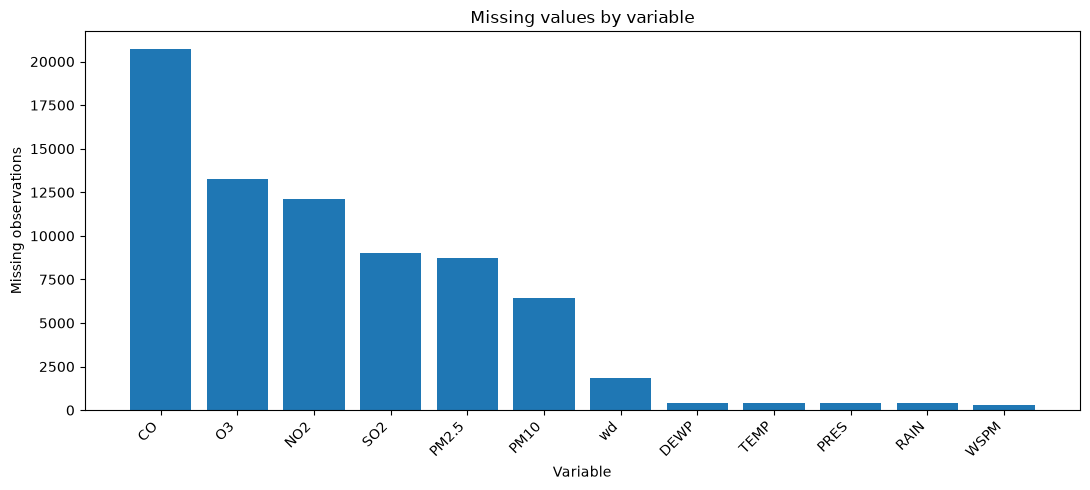

CO       20701
O3       13277
NO2      12116
SO2       9021
PM2.5     8739
PM10      6449
wd        1822
DEWP       403
TEMP       398
PRES       393
RAIN       390
WSPM       318
dtype: int64

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(11, 5))
plt.bar(missing.index, missing.values)
plt.title("Missing values by variable")
plt.xlabel("Variable")
plt.ylabel("Missing observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

missing

## 5. Visualization 2 — target distribution

PM2.5 is right-skewed, with many ordinary readings and fewer extreme pollution events. This means RMSE will penalize large errors strongly, while MAE will show the typical absolute error more robustly. Extremely impossible target values are excluded, but legitimate high-pollution readings remain.

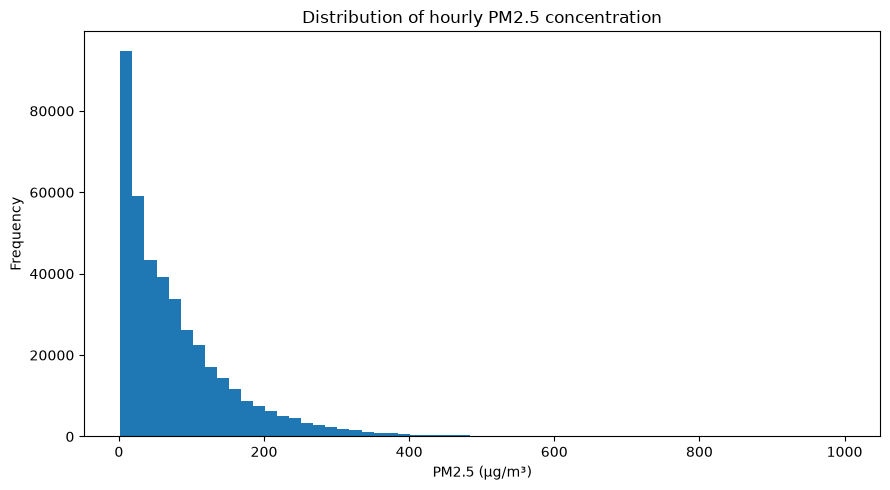

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(df["PM2.5"].dropna(), bins=60)
plt.title("Distribution of hourly PM2.5 concentration")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Visualization 3 — correlation heatmap

The heatmap helps identify which numeric measurements are strongly related to PM2.5. Pollutant variables such as PM10, CO, and NO2 are expected to carry substantial predictive information, while weather variables add context for dispersion and accumulation.

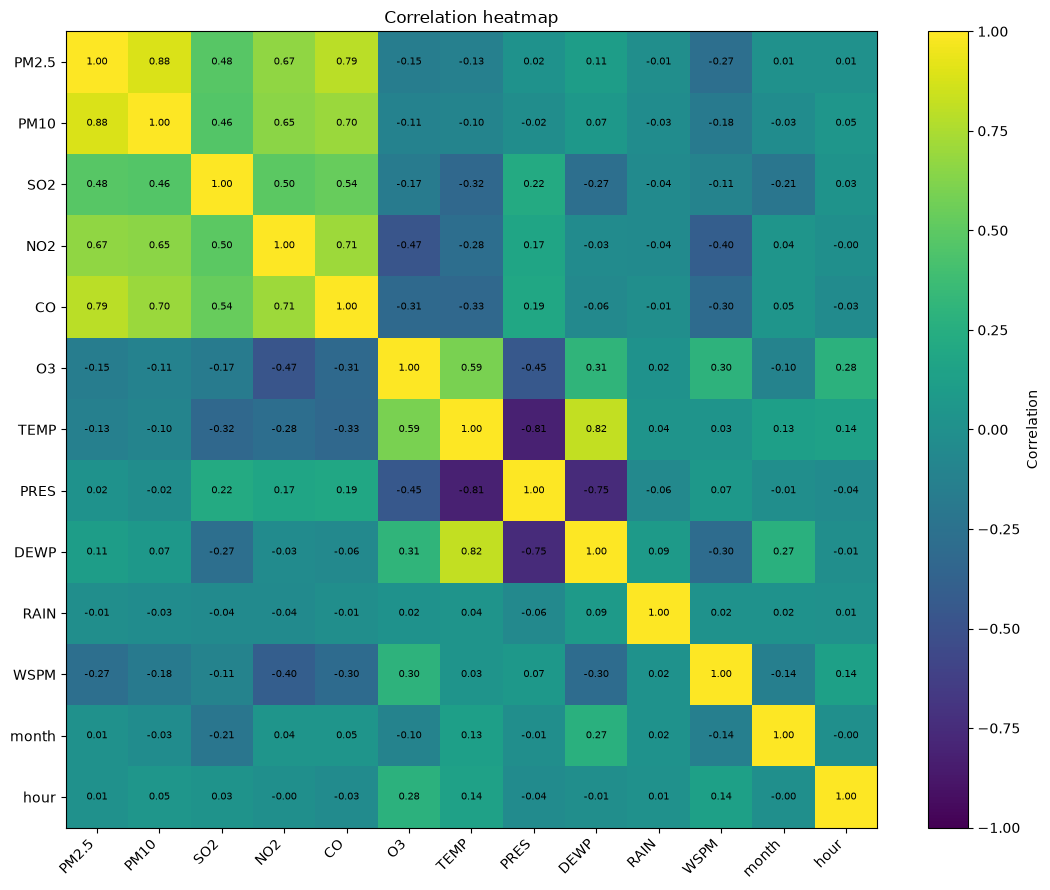

PM2.5    1.000000
PM10     0.884380
CO       0.789998
NO2      0.666948
SO2      0.482354
DEWP     0.114656
PRES     0.018566
hour     0.011709
month    0.010438
RAIN    -0.014359
TEMP    -0.131127
O3      -0.149697
WSPM    -0.272205
Name: PM2.5, dtype: float64

In [7]:
numeric_for_correlation = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "month", "hour"
]
corr = df[numeric_for_correlation].corr()

plt.figure(figsize=(11, 9))
image = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(image, label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for row in range(len(corr.index)):
    for col in range(len(corr.columns)):
        plt.text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=7)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

corr["PM2.5"].sort_values(ascending=False)

## 7. Visualization 4 — PM10 versus PM2.5

This scatter plot shows a strong positive but imperfect relationship. The spread and curvature suggest that a linear model can provide a useful baseline, while tree models may capture nonlinear interactions more effectively.

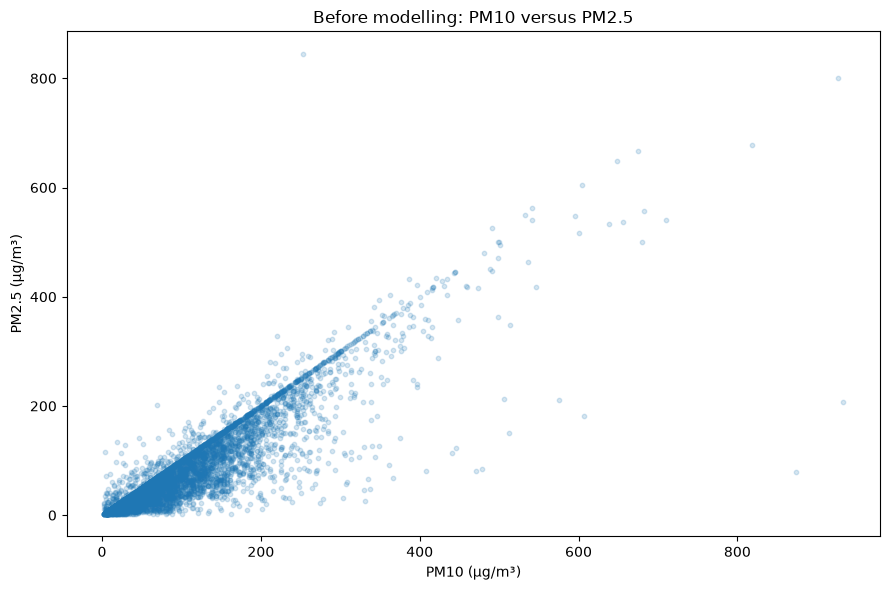

In [8]:
scatter_sample = df[["PM10", "PM2.5"]].dropna().sample(n=6000, random_state=RANDOM_STATE)
plt.figure(figsize=(9, 6))
plt.scatter(scatter_sample["PM10"], scatter_sample["PM2.5"], alpha=0.18, s=10)
plt.title("Before modelling: PM10 versus PM2.5")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.show()

## 8. Feature engineering and cleaning decisions

- Drop `No`: it is a row identifier, not an environmental measurement.
- Drop `year` and `day`: these exact historical values can encourage memorization. `month` and `hour` preserve useful seasonal and daily patterns.
- Keep five other pollutants, six weather/time numeric predictors, wind direction, and station.
- Convert `wd` and `station` to numeric one-hot columns.
- Remove rows with missing `PM2.5` because the model cannot learn without a target.
- Impute missing predictors using statistics learned only from the training split.
- Standardize numeric predictors because both gradient-descent linear algorithms are sensitive to feature scale.
- Use identical train, validation, and test partitions for all four algorithms so the comparison is fair.

In [9]:
TARGET = "PM2.5"
NUMERIC_FEATURES = [
    "month", "hour", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]
CATEGORICAL_FEATURES = ["wd", "station"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

model_df = df[FEATURES + [TARGET]].copy()
model_df = model_df.dropna(subset=[TARGET])
model_df = model_df[model_df[TARGET].between(0, 1000)]

# The original dataset remains rich; this configurable sample keeps training practical.
SAMPLE_SIZE = 120_000
if len(model_df) > SAMPLE_SIZE:
    model_df = model_df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

print("Rows used for modelling:", len(model_df))
model_df.head()

Rows used for modelling: 120000


,month,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station,PM2.5
77509,1,13,105.0,81.0,51.0,2000.0,27.0,6.7,1006.7,-7.0,0.0,1.6,SW,Dingling,95.0
336705,7,9,112.0,2.0,86.0,1200.0,NaN,28.5,998.1,23.9,0.0,1.0,E,Tiantan,110.0
296332,12,4,8.0,3.0,21.0,300.0,9.0,-4.6,1034.0,-20.0,0.0,3.5,NW,Shunyi,8.0
103958,1,14,33.0,9.0,8.0,400.0,73.0,6.1,1010.7,-10.6,0.0,5.5,WNW,Dingling,23.0
414268,6,4,100.0,12.0,63.0,1200.0,27.0,19.0,1002.6,9.2,0.0,1.3,NE,Wanshouxigong,55.0


## 9. Train, validation, and test split

The validation split is used to choose SGD hyperparameters. The untouched test split is used for final model comparison.

In [10]:
X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

Train: (84000, 14)
Validation: (18000, 14)
Test: (18000, 14)


## 9.1 Create a labeled CSV for the retraining demo

A small sample of held-out rows is saved for demonstrating `POST /retrain` in Swagger UI. It contains the 14 predictor columns and the `PM2.5` target. It should be used only for the endpoint demonstration, not as a replacement for the full dataset.

In [11]:
retraining_demo = X_test.copy()
retraining_demo[TARGET] = y_test
retraining_demo = retraining_demo.sample(
    n=min(3000, len(retraining_demo)),
    random_state=RANDOM_STATE,
)
retraining_demo_path = ROOT / "data" / "retraining_demo.csv"
retraining_demo.to_csv(retraining_demo_path, index=False)
print("Saved retraining demo CSV:", retraining_demo_path)

Saved retraining demo CSV: C:\Users\Administrator\Downloads\air_quality_regression_assignment_updated\linear_regression_model\data\retraining_demo.csv


## 10. Preprocessing pipeline

`ColumnTransformer` applies median imputation and standardization to numeric columns, and mode imputation plus one-hot encoding to categorical columns. `handle_unknown="ignore"` prevents API failure if a future dataset contains a category not observed during the original fit. Dense transformed output is used because the custom batch-gradient-descent estimator performs NumPy matrix operations.

In [12]:
def build_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        sparse_threshold=0,
    )

preprocessor = build_preprocessor()
X_train_transformed = preprocessor.fit_transform(X_train)
X_validation_transformed = preprocessor.transform(X_validation)
X_test_transformed = preprocessor.transform(X_test)

print("Transformed training shape:", X_train_transformed.shape)

Transformed training shape: (84000, 40)


## 11. Optimize two linear regression algorithms based on gradient descent

The updated rubric requires two distinct linear regression implementations that learn through gradient descent.

- **Batch Gradient Descent Linear Regression:** calculates each gradient using the full training batch before updating the coefficients.
- **Stochastic Gradient Descent Linear Regression:** updates coefficients from individual observations or small internal batches, making training faster and noisier.

Both algorithms are tuned on the validation set. Batch gradient descent compares learning rate and L2 regularization. SGD compares learning rate, regularization strength, and learning-rate schedule.

In [13]:
def metrics(y_true, predictions):
    mse = mean_squared_error(y_true, predictions)
    return {
        "MSE": mse,
        "RMSE": math.sqrt(mse),
        "MAE": mean_absolute_error(y_true, predictions),
        "R2": r2_score(y_true, predictions),
    }

# Tune batch gradient descent on a deterministic subset to keep full-batch
# optimization practical, then refit the selected configuration on all rows.
rng = np.random.default_rng(RANDOM_STATE)
batch_tune_count = min(25_000, len(X_train_transformed))
batch_tune_indices = rng.choice(
    len(X_train_transformed), size=batch_tune_count, replace=False
)
X_batch_tune = X_train_transformed[batch_tune_indices]
y_batch_tune = y_train.iloc[batch_tune_indices]

batch_parameter_grid = list(ParameterGrid({
    "learning_rate": [0.003, 0.01],
    "l2_penalty": [0.0, 0.0001],
}))

batch_tuning_results = []
for params in batch_parameter_grid:
    candidate = BatchGradientDescentRegressor(
        n_epochs=120,
        tolerance=1e-7,
        **params,
    )
    candidate.fit(X_batch_tune, y_batch_tune)
    validation_predictions = candidate.predict(X_validation_transformed)
    score = metrics(y_validation, validation_predictions)
    batch_tuning_results.append({**params, **score})

batch_tuning_table = pd.DataFrame(batch_tuning_results).sort_values("RMSE")
print("Batch gradient descent tuning results")
display(batch_tuning_table)

sgd_parameter_grid = list(ParameterGrid({
    "alpha": [0.0001, 0.001],
    "eta0": [0.001, 0.01],
    "learning_rate": ["invscaling", "adaptive"],
}))

sgd_tuning_results = []
for params in sgd_parameter_grid:
    candidate = SGDRegressor(
        loss="squared_error",
        penalty="l2",
        max_iter=1500,
        tol=1e-3,
        average=True,
        random_state=RANDOM_STATE,
        **params,
    )
    candidate.fit(X_train_transformed, y_train)
    validation_predictions = candidate.predict(X_validation_transformed)
    score = metrics(y_validation, validation_predictions)
    sgd_tuning_results.append({**params, **score})

sgd_tuning_table = pd.DataFrame(sgd_tuning_results).sort_values("RMSE")
print("Stochastic gradient descent tuning results")
display(sgd_tuning_table)

Batch gradient descent tuning results


,l2_penalty,learning_rate,MSE,RMSE,MAE,R2
1,0.0000,0.010,1161.391605,34.079196,22.610133,0.820203
3,0.0001,0.010,1161.427372,34.079721,22.610242,0.820197
0,0.0000,0.003,2738.926290,52.334752,38.245269,0.575982
2,0.0001,0.003,2738.977048,52.335237,38.245265,0.575974


Stochastic gradient descent tuning results


,alpha,eta0,learning_rate,MSE,RMSE,MAE,R2
1,0.0001,0.001,adaptive,1.008430e+03,31.755793,20.584218,0.843883
2,0.0001,0.010,invscaling,1.008449e+03,31.756078,20.582576,0.843880
5,0.0010,0.001,adaptive,1.008507e+03,31.756993,20.579665,0.843871
6,0.0010,0.010,invscaling,1.008530e+03,31.757362,20.578250,0.843868
0,0.0001,0.001,invscaling,1.010616e+03,31.790193,20.531513,0.843545
4,0.0010,0.001,invscaling,1.010830e+03,31.793552,20.531621,0.843512
7,0.0010,0.010,adaptive,3.064234e+07,5535.552040,1220.740269,-4742.791582
3,0.0001,0.010,adaptive,4.484914e+07,6696.949990,1498.472225,-6942.170591


In [14]:
best_batch_gd_params = {
    "learning_rate": float(batch_tuning_table.iloc[0]["learning_rate"]),
    "l2_penalty": float(batch_tuning_table.iloc[0]["l2_penalty"]),
}

best_sgd_params = {
    key: sgd_tuning_table.iloc[0][key]
    for key in ["alpha", "eta0", "learning_rate"]
}
best_sgd_params["alpha"] = float(best_sgd_params["alpha"])
best_sgd_params["eta0"] = float(best_sgd_params["eta0"])

print("Best Batch GD hyperparameters:", best_batch_gd_params)
print("Best SGD hyperparameters:", best_sgd_params)

Best Batch GD hyperparameters: {'learning_rate': 0.01, 'l2_penalty': 0.0}
Best SGD hyperparameters: {'alpha': 0.0001, 'eta0': 0.001, 'learning_rate': 'adaptive'}


## 12. Train/test loss curves for both gradient-descent algorithms

For both linear models, MSE is recorded after every epoch on training and test data. Falling losses indicate learning. A large and growing gap between training and test loss can indicate overfitting. Batch gradient descent normally produces a smoother curve, while stochastic gradient descent can fluctuate because of its noisier updates.

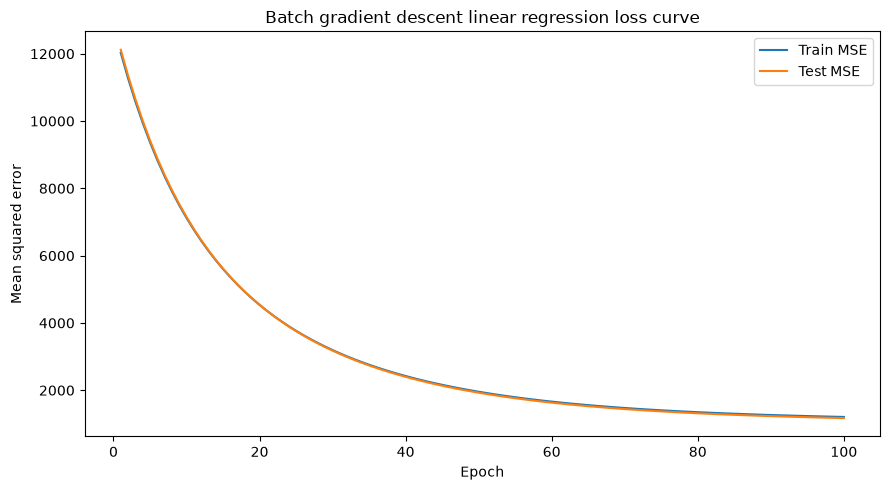

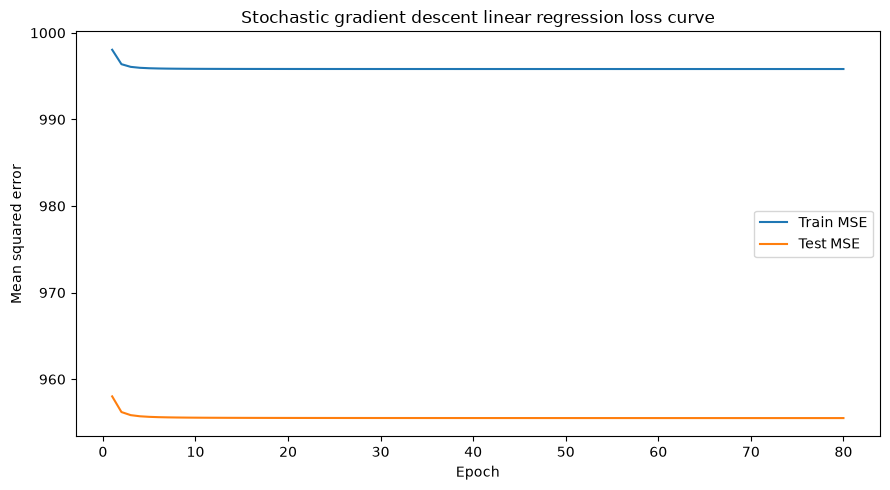

In [15]:
# Batch Gradient Descent loss curve
batch_weights = np.zeros(X_train_transformed.shape[1], dtype=float)
batch_intercept = 0.0
batch_train_losses = []
batch_test_losses = []
BATCH_EPOCHS = 100
batch_lr = best_batch_gd_params["learning_rate"]
batch_l2 = best_batch_gd_params["l2_penalty"]

for epoch in range(BATCH_EPOCHS):
    train_predictions = X_train_transformed @ batch_weights + batch_intercept
    errors = train_predictions - y_train.to_numpy()
    gradient_weights = (
        (2.0 / len(y_train)) * (X_train_transformed.T @ errors)
        + 2.0 * batch_l2 * batch_weights
    )
    gradient_intercept = 2.0 * errors.mean()
    batch_weights -= batch_lr * gradient_weights
    batch_intercept -= batch_lr * gradient_intercept

    batch_train_losses.append(mean_squared_error(
        y_train,
        X_train_transformed @ batch_weights + batch_intercept,
    ))
    batch_test_losses.append(mean_squared_error(
        y_test,
        X_test_transformed @ batch_weights + batch_intercept,
    ))

plt.figure(figsize=(9, 5))
plt.plot(range(1, BATCH_EPOCHS + 1), batch_train_losses, label="Train MSE")
plt.plot(range(1, BATCH_EPOCHS + 1), batch_test_losses, label="Test MSE")
plt.title("Batch gradient descent linear regression loss curve")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.tight_layout()
plt.show()

# Stochastic Gradient Descent loss curve
sgd_curve_model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    max_iter=1,
    tol=None,
    warm_start=True,
    average=True,
    random_state=RANDOM_STATE,
    **best_sgd_params,
)

sgd_train_losses = []
sgd_test_losses = []
SGD_EPOCHS = 80
for epoch in range(SGD_EPOCHS):
    sgd_curve_model.partial_fit(X_train_transformed, y_train)
    sgd_train_losses.append(mean_squared_error(
        y_train,
        sgd_curve_model.predict(X_train_transformed),
    ))
    sgd_test_losses.append(mean_squared_error(
        y_test,
        sgd_curve_model.predict(X_test_transformed),
    ))

plt.figure(figsize=(9, 5))
plt.plot(range(1, SGD_EPOCHS + 1), sgd_train_losses, label="Train MSE")
plt.plot(range(1, SGD_EPOCHS + 1), sgd_test_losses, label="Test MSE")
plt.title("Stochastic gradient descent linear regression loss curve")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Train the four required regression algorithms

The same prepared train/test split is used for every model. The two linear models both learn their coefficients through gradient descent. Decision Tree is the required standalone tree algorithm, while Random Forest is the required ensemble algorithm because it combines predictions from many decision trees.

In [16]:
final_batch_gd_model = BatchGradientDescentRegressor(
    n_epochs=150,
    tolerance=1e-8,
    **best_batch_gd_params,
)
final_batch_gd_model.fit(X_train_transformed, y_train)

batch_gd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_batch_gd_model),
])

final_sgd_model = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    max_iter=1500,
    tol=1e-3,
    average=True,
    random_state=RANDOM_STATE,
    **best_sgd_params,
)
final_sgd_model.fit(X_train_transformed, y_train)

sgd_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_sgd_model),
])

decision_tree_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", DecisionTreeRegressor(
        max_depth=20,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
    )),
])

random_forest_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=60,
        max_depth=16,
        min_samples_leaf=5,
        max_features=0.7,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

decision_tree_pipeline.fit(X_train, y_train)
random_forest_pipeline.fit(X_train, y_train)

models = {
    "Batch Gradient Descent Linear Regression": batch_gd_pipeline,
    "Stochastic Gradient Descent Linear Regression": sgd_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest (Ensemble)": random_forest_pipeline,
}

## 14. Compare all four algorithms using the same loss metrics

The best model is selected by the lowest test RMSE. MSE is reported as the main squared-error loss, MAE gives the typical absolute prediction error, and R² shows the proportion of target variation explained. Using the same untouched test data makes the four-way comparison fair.

In [17]:
comparison_rows = []
predictions_by_model = {}
for name, model in models.items():
    predictions = model.predict(X_test)
    predictions_by_model[name] = predictions
    comparison_rows.append({"Model": name, **metrics(y_test, predictions)})

comparison = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
comparison

,Model,MSE,RMSE,MAE,R2
0,Random Forest (Ensemble),443.943261,21.069961,13.245445,0.932888
1,Decision Tree,699.640150,26.450712,16.155078,0.894234
2,Stochastic Gradient Descent Linear Regression,955.559821,30.912131,20.494886,0.855547
3,Batch Gradient Descent Linear Regression,1050.308727,32.408467,21.714893,0.841223


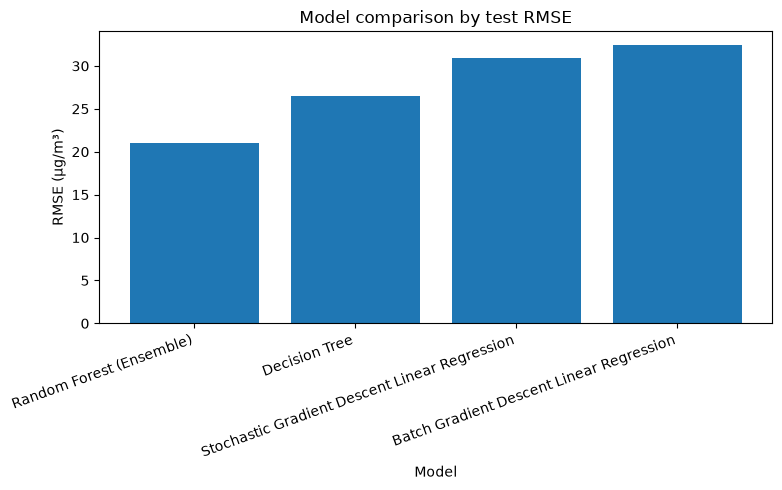

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["RMSE"])
plt.title("Model comparison by test RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (µg/m³)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 15. Before and after linear-fit visualization

A multivariate model cannot be represented by one line in two dimensions. To satisfy the line-fit visualization meaningfully, PM10—the strongest simple numeric predictor—is isolated. The first plot above showed the raw relationship; this plot adds a univariate regression line as a clear visual explanation of linear fitting. The deployed model still uses all 14 variables.

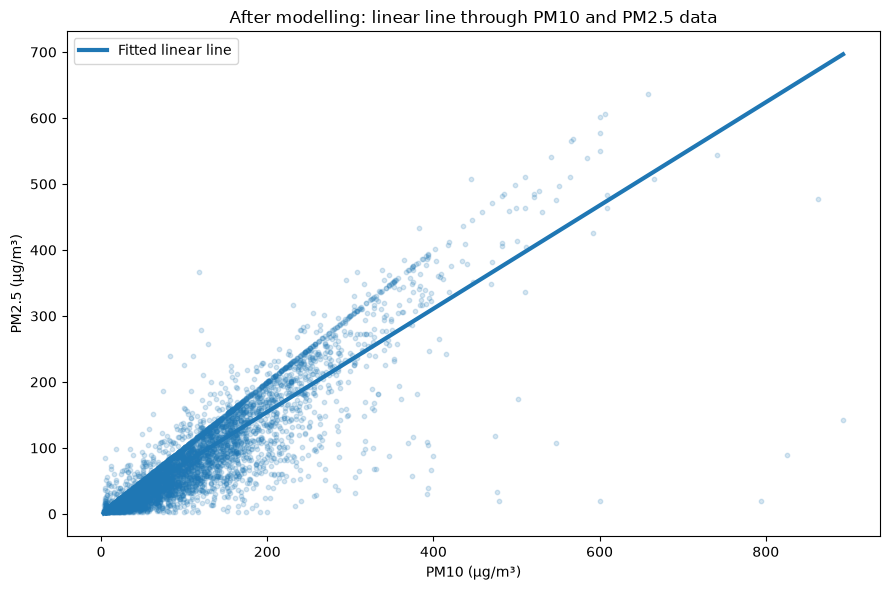

In [19]:
line_data = model_df[["PM10", TARGET]].dropna().sample(n=6000, random_state=RANDOM_STATE)
line_model = LinearRegression()
line_model.fit(line_data[["PM10"]], line_data[TARGET])

x_line = np.linspace(line_data["PM10"].min(), line_data["PM10"].max(), 300)
y_line = line_model.predict(pd.DataFrame({"PM10": x_line}))

plt.figure(figsize=(9, 6))
plt.scatter(line_data["PM10"], line_data[TARGET], alpha=0.18, s=10)
plt.plot(x_line, y_line, linewidth=3, label="Fitted linear line")
plt.title("After modelling: linear line through PM10 and PM2.5 data")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Actual versus predicted values for the best model

Points close to the diagonal indicate accurate predictions. This plot is more appropriate than a single line for evaluating a multivariate model.

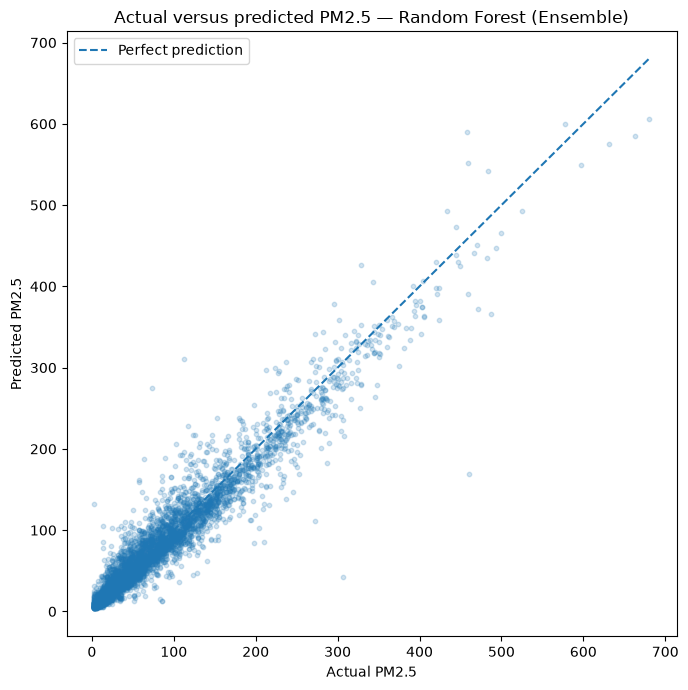

In [20]:
best_model_name = comparison.iloc[0]["Model"]
best_model = models[best_model_name]
best_predictions = predictions_by_model[best_model_name]

plot_count = min(5000, len(y_test))
plot_indices = np.random.default_rng(RANDOM_STATE).choice(len(y_test), plot_count, replace=False)
actual_sample = y_test.iloc[plot_indices].to_numpy()
predicted_sample = best_predictions[plot_indices]

minimum = min(actual_sample.min(), predicted_sample.min())
maximum = max(actual_sample.max(), predicted_sample.max())

plt.figure(figsize=(7, 7))
plt.scatter(actual_sample, predicted_sample, alpha=0.2, s=10)
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect prediction")
plt.title(f"Actual versus predicted PM2.5 — {best_model_name}")
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Save the best-performing model

The best model among all four algorithms is selected using the lowest test RMSE. The entire pipeline is saved—not only the estimator—so the API applies the exact same feature transformations. Metadata records the selected model, feature order, gradient-descent hyperparameters, and all evaluation metrics.

In [21]:
MODEL_PATH = MODEL_DIR / "best_model.joblib"
METADATA_PATH = MODEL_DIR / "model_metadata.json"

joblib.dump(best_model, MODEL_PATH, compress=3)
metadata = {
    "best_model_name": best_model_name,
    "target": TARGET,
    "unit": "µg/m³",
    "feature_columns": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "metrics": comparison.set_index("Model").to_dict(orient="index"),
    "best_batch_gd_params": best_batch_gd_params,
    "best_sgd_params": best_sgd_params,
    "training_rows": len(model_df),
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved model:", MODEL_PATH)
print("Saved metadata:", METADATA_PATH)
print("Best model:", best_model_name)

Saved model: C:\Users\Administrator\Downloads\air_quality_regression_assignment_updated\linear_regression_model\models\best_model.joblib
Saved metadata: C:\Users\Administrator\Downloads\air_quality_regression_assignment_updated\linear_regression_model\models\model_metadata.json
Best model: Random Forest (Ensemble)


## 18. Make a prediction using one test row

This is the same type of one-row prediction the FastAPI endpoint will perform.

In [22]:
test_position = 0
one_test_row = X_test.iloc[[test_position]]
actual_value = float(y_test.iloc[test_position])
predicted_value = float(best_model.predict(one_test_row)[0])

print("Input values:")
display(one_test_row)
print(f"Actual PM2.5: {actual_value:.2f} µg/m³")
print(f"Predicted PM2.5: {predicted_value:.2f} µg/m³")
print(f"Absolute error: {abs(actual_value - predicted_value):.2f} µg/m³")

Input values:


,month,hour,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station
370955,6,11,177.0,14.0,48.0,1500.0,102.0,25.8,996.6,19.2,0.0,0.8,ESE,Wanliu


Actual PM2.5: 177.00 µg/m³
Predicted PM2.5: 162.39 µg/m³
Absolute error: 14.61 µg/m³


## 19. Interpretation and further improvement

Use the actual table values when recording the video.

- **Four required comparisons:** Batch Gradient Descent Linear Regression, Stochastic Gradient Descent Linear Regression, Decision Tree, and Random Forest ensemble.
- **Is loss high or low?** Compare RMSE and MAE with the target distribution and standard deviation. A useful model should improve meaningfully over predicting the training mean.
- **How do the gradient methods differ?** Batch GD uses the full training set for each coefficient update and therefore has a smooth but computationally heavier learning path. SGD makes frequent noisier updates and can reach a useful solution faster on large data.
- **Why might Random Forest win?** Pollution depends on nonlinear interactions and thresholds among pollutants, weather, time, and location. A forest can model these interactions more flexibly than one linear equation or one tree.
- **Hyperparameters:** Batch GD learning rate, epochs, tolerance, and L2 penalty; SGD learning rate, alpha, epochs, penalty, and schedule; Decision Tree depth and minimum leaf size; Random Forest tree count, depth, feature sampling, and leaf size.
- **Further reduction:** use chronological validation, add lagged PM2.5 and rolling averages, engineer cyclical hour/month features, tune with cross-validation, model station-specific patterns, and retrain with newer local data.
- **New data:** call the protected `/retrain` endpoint with a labeled CSV, retrain and compare all four algorithms, save a versioned pipeline, and monitor data drift before promotion.